# **Titanic**

In this project, a machine learning classification model is developed to predict passenger survival using data from the Titanic disaster.
The objective of the study is to estimate survival outcomes based on passengers’ demographic and travel-related features. 

Data Dictionary

The dataset contains demographic and travel-related information of Titanic passengers, including passenger class, gender, age, family relationships, and port of embarkation. The target variable, Survival, is a binary indicator representing whether a passenger survived the disaster

<img src='https://i.etsystatic.com/52778019/r/il/880fff/6475184378/il_fullxfull.6475184378_6w9d.jpg'>
<a href='https://www.kaggle.com/competitions/titanic' target=_blank>
Click here for the dataset file</a>

**Import library**

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Import Data**

In [6]:
df = pd.read_csv("ttrain.csv")

**Features and Target**

In [7]:
x = df.drop("Survived", axis=1)
y = df["Survived"]

In [9]:
# Numerical and categorical features are identified automatically

num_cols = x.select_dtypes(include=["int64", "float64"]).columns
cat_cols = x.select_dtypes(include=["object"]).columns

**Data Preprocessing**

In [ ]:
# Missing values are handled and categorical variables are encoded

In [10]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [11]:
# Different preprocessing steps are applied to numerical and categorical features
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

**Visualisation**

In [ ]:
# Age patterns among survivors and non-survivors

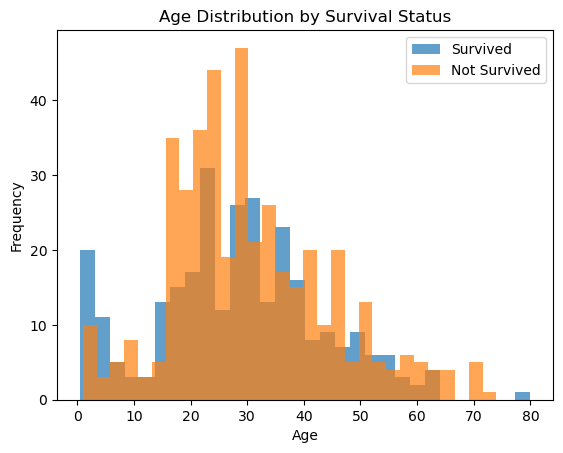

In [33]:
plt.hist(df[df["Survived"] == 1]["Age"], bins=30, alpha=0.7, label="Survived")
plt.hist(df[df["Survived"] == 0]["Age"], bins=30, alpha=0.7, label="Not Survived")

plt.title("Age Distribution by Survival Status")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()


**Model Pipeline**

In [ ]:
# Logistic Regression is used as a classification model with increased iterations

In [27]:
model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])

In [28]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

**Model Training**

In [31]:
model.fit(x_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object'))])),
                ('clf', LogisticRegression(max_iter=1000))])

**Model Evaluation**

In [19]:
# The model performance is evaluated using accuracy and classification metrics

y_pred = model.predict(x_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.8212290502793296
[[92 13]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



**Test Set Prediction**

In [20]:
test_df = pd.read_csv("ttest.csv")
test_preds = model.predict(test_df)

**Submission**

In [21]:
submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": test_preds
})

submission.to_csv("submission.csv", index=False)

**Summary**

The model achieved an accuracy of 82% and demonstrated balanced performance across both classes. Gender appears to be a strong factor influencing survival outcomes